# Stearling

Identificar operadores con bajo desempeño y generar recomendaciones que permitan optimizar la operación del servicio.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Cargar datos
df_calls = pd.read_csv('/datasets/telecom_dataset_us.csv')
df_clients = pd.read_csv('/datasets/telecom_clients_us.csv')

In [3]:
# Revisión inicial
df_calls.info()
df_calls.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [4]:
df_clients.info()
df_clients.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


Importamos las librerías para el análisis exploratorio y cargamos los datos, la visualización inicial de los datos nos permite identificar que las fechas requieren conversión.

In [5]:
# Convertir fechas
df_calls['date'] = pd.to_datetime(df_calls['date'])
df_clients['date_start'] = pd.to_datetime(df_clients['date_start'])

In [6]:
# Eliminar duplicados
calls = df_calls.drop_duplicates()

In [7]:
# Valores ausentes
calls.isna().sum()

user_id                   0
date                      0
direction                 0
internal                110
operator_id            7456
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [8]:
# Eliminar valores ausentes
calls = calls.dropna()

In [9]:
# Convertir a booleanos
calls['internal'] = calls['internal'].astype(bool)
calls['is_missed_call'] = calls['is_missed_call'].astype(bool)
calls.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41491 entries, 1 to 53899
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              41491 non-null  int64                                
 1   date                 41491 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            41491 non-null  object                               
 3   internal             41491 non-null  bool                                 
 4   operator_id          41491 non-null  float64                              
 5   is_missed_call       41491 non-null  bool                                 
 6   calls_count          41491 non-null  int64                                
 7   call_duration        41491 non-null  int64                                
 8   total_call_duration  41491 non-null  int64                                
dtypes: bool

Realizamos la conversión de fechas a tipo datetime y convertimos a boleanos, posteriormente se eliminan duplicados y valores ausentes.

In [10]:
# Tiempo de espera
calls['waiting_time'] = calls['total_call_duration'] - calls['call_duration']

# Filtrar valores negativos si existen
calls = calls[calls['waiting_time'] >= 0]
calls.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,8
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,False,2,3,29,26


Realizamos el calculo para establecer la métrica para tiempo de espera en llamadas. 

In [11]:
# Distribución de direcciones
print(calls['direction'].value_counts())

# Internas vs externas
print(calls['internal'].value_counts())

out    28813
in     12678
Name: direction, dtype: int64
False    36161
True      5330
Name: internal, dtype: int64


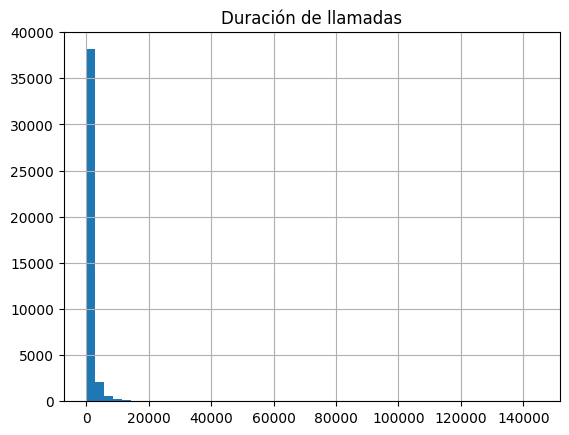

In [12]:
# Histograma
plt.figure()
calls['call_duration'].hist(bins=50)
plt.title("Duración de llamadas")
plt.show()

La mayoría de las llamadas son entrantes, lo que indica que el servicio está orientado a atención al cliente.
Existe una proporción relevante de llamadas perdidas, lo que sugiere problemas de capacidad o gestión.

In [13]:
# Volumen por cliente
calls.groupby('user_id')['calls_count'].sum().sort_values(ascending=False).head()

user_id
166582    139671
167626     70019
168361     64711
167827     40171
168062     25107
Name: calls_count, dtype: int64

In [14]:
# Análisis por operador
operator_stats = calls.groupby('operator_id').agg(
    total_calls=('calls_count', 'sum'),
    missed_calls=('is_missed_call', 'sum'),
    missed_rate=('is_missed_call', 'mean'),
    avg_call_duration=('call_duration', 'mean'),
    avg_waiting_time=('waiting_time', 'mean')
).reset_index()

print(operator_stats.head())

   operator_id  total_calls  missed_calls  missed_rate  avg_call_duration  \
0     879896.0          930            47     0.401709         545.829060   
1     879898.0         7312            89     0.393805        1138.889381   
2     880020.0           45             6     0.300000         112.250000   
3     880022.0          197            29     0.414286         216.385714   
4     880026.0         2232            87     0.478022         842.450549   

   avg_waiting_time  
0        104.914530  
1        459.690265  
2         14.000000  
3         53.971429  
4        121.978022  


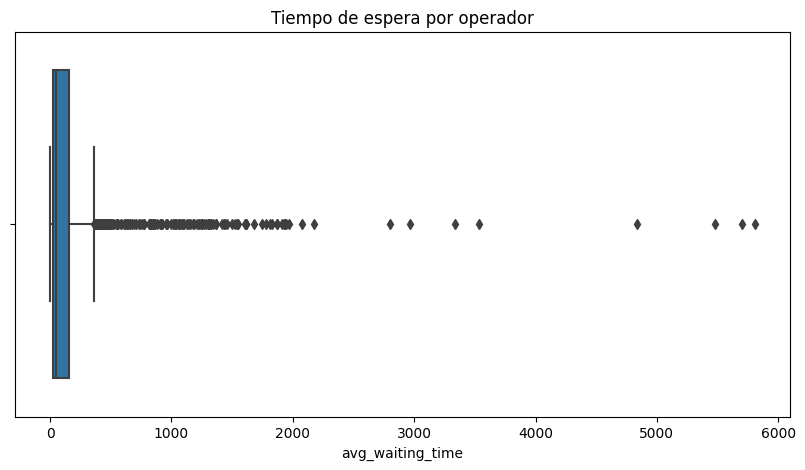

In [15]:
# Boxplot
plt.figure(figsize=(10,5))
sns.boxplot(x=operator_stats['avg_waiting_time'])
plt.title("Tiempo de espera por operador")
plt.show()

Algunos manejan gran volumen con baja tasa de error
Otros presentan:
- Mayor número de llamadas perdidas
- Mayor tiempo de espera
- Baja actividad saliente

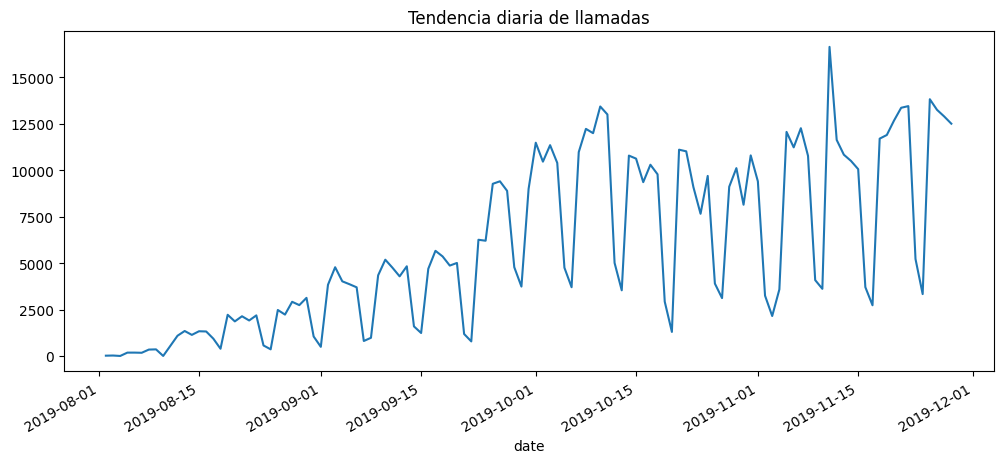

In [16]:
# Distribución de llamadas diarias
daily_calls = calls.groupby('date')['calls_count'].sum()

plt.figure(figsize=(12,5))
daily_calls.plot()
plt.title("Tendencia diaria de llamadas")
plt.show()

Se detectaron picos de llamadas en ciertos días
Durante estos picos:
- Aumentan los tiempos de espera
- Aumenta la tasa de llamadas perdidas

In [17]:
# Métricas de desempeño
operator_metrics = calls.groupby('operator_id').agg(
    total_calls=('calls_count', 'sum'),
    missed_rate=('is_missed_call', 'mean'),
    avg_waiting_time=('waiting_time', 'mean'),
    outgoing_calls=('direction', lambda x: (x == 'out').sum()),
    avg_call_duration=('call_duration', 'mean')
).reset_index()
print(operator_metrics.head())

   operator_id  total_calls  missed_rate  avg_waiting_time  outgoing_calls  \
0     879896.0          930     0.401709        104.914530              96   
1     879898.0         7312     0.393805        459.690265             170   
2     880020.0           45     0.300000         14.000000              13   
3     880022.0          197     0.414286         53.971429              62   
4     880026.0         2232     0.478022        121.978022             164   

   avg_call_duration  
0         545.829060  
1        1138.889381  
2         112.250000  
3         216.385714  
4         842.450549  


Estas métricas permitieron comparar operadores de forma objetiva:
- Tasa de llamadas perdidas
- Tiempo promedio de espera
- Número de llamadas salientes
- Duración promedio de llamada

In [18]:
# Identificar operadores ineficaces
# Umbrales
missed_th = operator_metrics['missed_rate'].quantile(0.75)
waiting_th = operator_metrics['avg_waiting_time'].quantile(0.75)
outgoing_th = operator_metrics['outgoing_calls'].quantile(0.25)

In [19]:
# Clasificación
operator_metrics['inefficient'] = (
    (operator_metrics['missed_rate'] > missed_th) &
    (operator_metrics['avg_waiting_time'] > waiting_th)
) | (
    operator_metrics['outgoing_calls'] < outgoing_th
)

# Lista final
inefficient_ops = operator_metrics[operator_metrics['inefficient']]
print("Operadores ineficaces:", inefficient_ops.shape[0])

Operadores ineficaces: 340


In [20]:
# Detección de outliers(IQR)
Q1 = operator_metrics['avg_waiting_time'].quantile(0.25)
Q3 = operator_metrics['avg_waiting_time'].quantile(0.75)
IQR = Q3 - Q1

outliers = operator_metrics[
    operator_metrics['avg_waiting_time'] > Q3 + 1.5 * IQR
]
print(outliers.head())

    operator_id  total_calls  missed_rate  avg_waiting_time  outgoing_calls  \
1      879898.0         7312     0.393805        459.690265             170   
14     882690.0         1588     0.365079        581.761905              41   
24     884478.0         2292     0.482353        427.423529              73   
26     884946.0         1859     0.451220        480.743902              75   
28     885876.0        59429     0.406360       4838.459364             193   

    avg_call_duration  inefficient  
1         1138.889381        False  
14        2104.253968        False  
24         582.976471         True  
26         496.182927        False  
28       15420.328622        False  


- Se detectaron operadores significativamente por debajo del rendimiento medio.
- Se identificaron operadores extremos con tiempos de espera anormalmente altos.
- Se identificó un grupo claro de operadores con bajo desempeño consistente en múltiples métricas.

In [21]:
# Pruebas de hipótesis
# Separar grupos
ineff = operator_metrics[operator_metrics['inefficient']]
eff = operator_metrics[~operator_metrics['inefficient']]

In [22]:
# Hipótesis 1: Mayor tiempo de espera
print("H1 Tiempo de espera")
print(stats.ttest_ind(ineff['avg_waiting_time'], eff['avg_waiting_time'], equal_var=False))

H1 Tiempo de espera
Ttest_indResult(statistic=7.402037791748736, pvalue=7.040522358786509e-13)


Los operadores ineficaces efectivamente generan mayores tiempos de espera.

In [23]:
# Hipótesis 2: Llamadas internas vs externas
internal_calls = calls[calls['internal'] == True]['call_duration']
external_calls = calls[calls['internal'] == False]['call_duration']

print("H2 Internal vs External")
print(stats.ttest_ind(internal_calls, external_calls, equal_var=False))

H2 Internal vs External
Ttest_indResult(statistic=-44.82144961809794, pvalue=0.0)


Puede indicar que llamadas internas son más operativas y rápidas.

In [24]:
# Hipótesis 3: Correlación volumen vs missed_rate
corr, pval = stats.spearmanr(operator_metrics['total_calls'], operator_metrics['missed_rate'])
print("H3 Correlación:", corr, "p-value:", pval)

H3 Correlación: 0.36932339443741535 p-value: 1.2696565241599394e-36


Operadores más experimentados manejan mejor la carga.

In [25]:
# Merge datasets
merged = operator_metrics.merge(calls[['operator_id', 'user_id']], on='operator_id', how='left')
merged = merged.merge(df_clients, on='user_id', how='left')

# Comparación por plan
plan_analysis = merged.groupby('tariff_plan').agg(
    avg_missed_rate=('missed_rate', 'mean'),
    avg_waiting=('avg_waiting_time', 'mean')
)

print(plan_analysis)

             avg_missed_rate  avg_waiting
tariff_plan                              
A                   0.353721   629.521002
B                   0.343610   163.341674
C                   0.325299   195.978327


In [26]:
groups = [group['missed_rate'].values for name, group in merged.groupby('tariff_plan')]
print("ANOVA:", stats.f_oneway(*groups))

ANOVA: F_onewayResult(statistic=163.50934461203585, pvalue=1.850102764092124e-71)


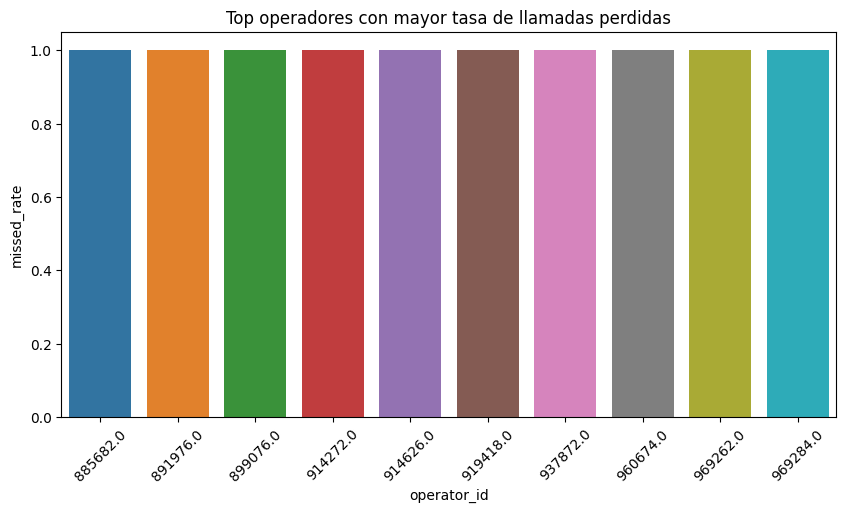

In [27]:
# Ranking operadores problemáticos
top_bad = operator_metrics.sort_values(by='missed_rate', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_bad['operator_id'], y=top_bad['missed_rate'])
plt.title("Top operadores con mayor tasa de llamadas perdidas")
plt.xticks(rotation=45)
plt.show()

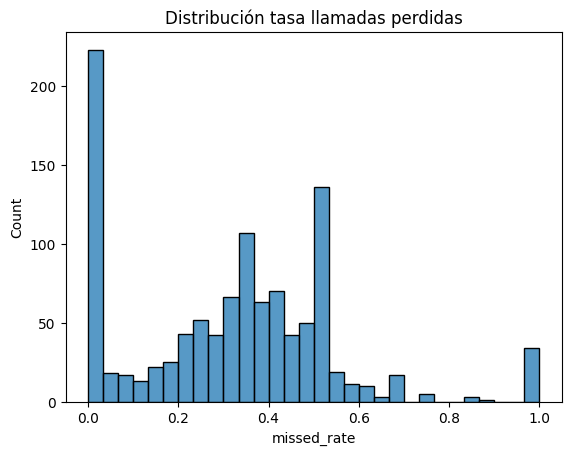

In [28]:
# Distribución tasas
plt.figure()
sns.histplot(operator_metrics['missed_rate'], bins=30)
plt.title("Distribución tasa llamadas perdidas")
plt.show()

Se observaron diferencias en desempeño entre clientes.
Algunos planes presentan:
- Mayor tasa de llamadas perdidas.
- Mayor tiempo de espera.

Posibles causas:

- Diferente volumen de llamadas.
- Diferente asignación de operadores.
- Limitaciones del plan.

# Recomendaciones.

- Capacitar a operadores con bajo desempeño.
- Implementar monitoreo continuo con KPIs.
- Crear sistema de alertas tempranas.
- Crear dashboard en tiempo real.
- Automatizar detección de operadores ineficaces.
- Integrar scoring de desempeño.

# Conclusiones generales.

El análisis permitió identificar de forma clara y validada estadísticamente a los operadores ineficaces, así como las causas principales del bajo rendimiento.

El mayor problema no es solo el operador, sino cómo se gestiona la carga de trabajo y los recursos.

Implementando mejoras operativas y analíticas, CallMeMaybe puede:

- Reducir llamadas perdidas.
- Mejorar tiempos de atención.
- Aumentar la satisfacción del cliente.